Import

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from pathlib import Path
from IPython.display import display

In [1]:
import matplotlib
print(matplotlib.__version__)

3.11.2


Data Path  


In [4]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "messages.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

Project root: c:\Dev\PickyTalker
Dataset path: c:\Dev\PickyTalker\data\processed\messages.csv
Exists: True


load the dataset and get info/overview


In [5]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.info()

column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isnull().sum().values,
    "unique_values": df.nunique().values
})

column_summary

C:\Users\bhana\AppData\Local\Temp\ipykernel_21752\3905194693.py:1: DtypeWarning: Columns (9: act, 10: emotion) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Shape: (231089, 11)
Rows: 231089
Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 231089 entries, 0 to 231088
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   conversation_id  231089 non-null  str  
 1   speaker_id       231089 non-null  str  
 2   message_id       231089 non-null  str  
 3   message          231089 non-null  str  
 4   dataset          231089 non-null  str  
 5   split            231089 non-null  str  
 6   speaker_id_type  231089 non-null  str  
 7   source_row       231089 non-null  int64
 8   turn_index       231089 non-null  int64
 9   act              99651 non-null   str  
 10  emotion          99651 non-null   str  
dtypes: int64(2), str(9)
memory usage: 19.4 MB


,column,dtype,missing_values,unique_values
conversation_id,conversation_id,str,0,22057
speaker_id,speaker_id,str,0,43926
message_id,message_id,str,0,231089
message,message,str,0,205254
dataset,dataset,str,0,2
split,split,str,0,4
speaker_id_type,speaker_id_type,str,0,1
source_row,source_row,int64,0,11118
turn_index,turn_index,int64,0,50
act,act,str,131438,5752


message, plot message per convo and its lenght

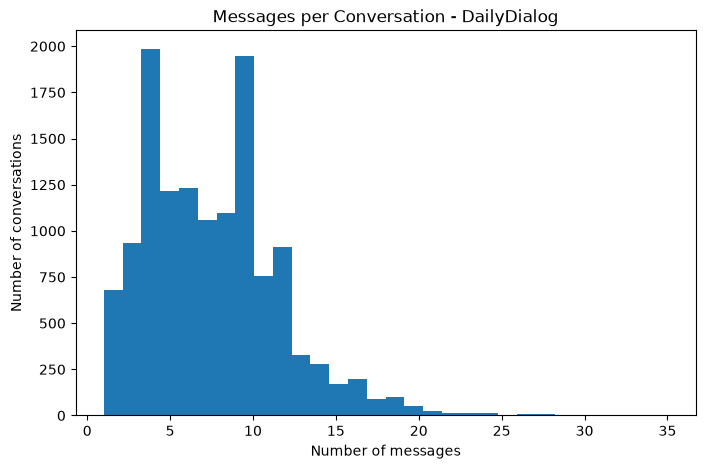

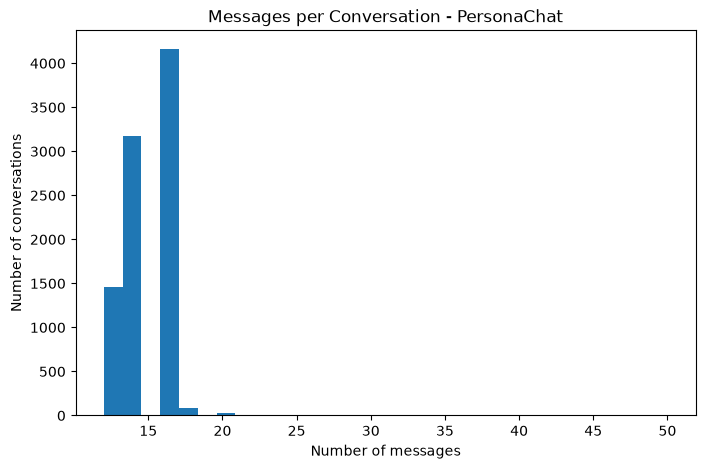

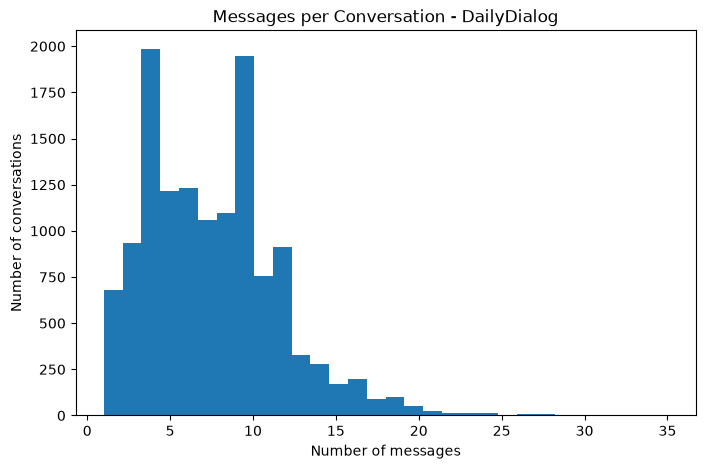

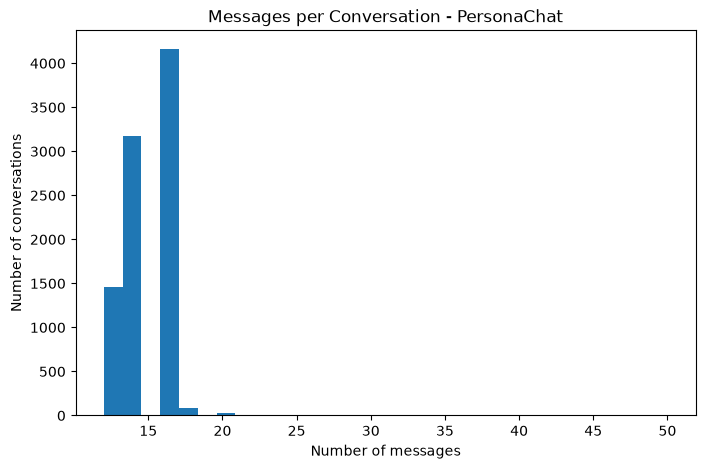

In [6]:
messages_per_conversation = (
    df.groupby(["dataset", "conversation_id"])
    .size()
    .reset_index(name="message_count")
)

messages_per_conversation.groupby("dataset")["message_count"].describe()

for dataset in messages_per_conversation["dataset"].unique():
    values = messages_per_conversation.loc[
        messages_per_conversation["dataset"] == dataset,
        "message_count"
    ]

    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=30)
    plt.title(f"Messages per Conversation - {dataset}")
    plt.xlabel("Number of messages")
    plt.ylabel("Number of conversations")
    plt.show()


for dataset in messages_per_conversation["dataset"].unique():
    values = messages_per_conversation.loc[
        messages_per_conversation["dataset"] == dataset,
        "message_count"
    ]

    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=30)
    plt.title(f"Messages per Conversation - {dataset}")
    plt.xlabel("Number of messages")
    plt.ylabel("Number of conversations")
    plt.show()

Lenght


In [7]:
df["character_count"] = df["message"].astype(str).str.len()

df["word_count"] = (
    df["message"]
    .astype(str)
    .str.split()
    .str.len()
)

df[["character_count", "word_count"]].describe()

,character_count,word_count
count,231089.000000,231089.000000
mean,54.057835,12.485168
std,35.365472,7.433530
min,1.000000,1.000000
25%,33.000000,8.000000
50%,48.000000,11.000000
75%,66.000000,15.000000
max,1158.000000,261.000000


Word count

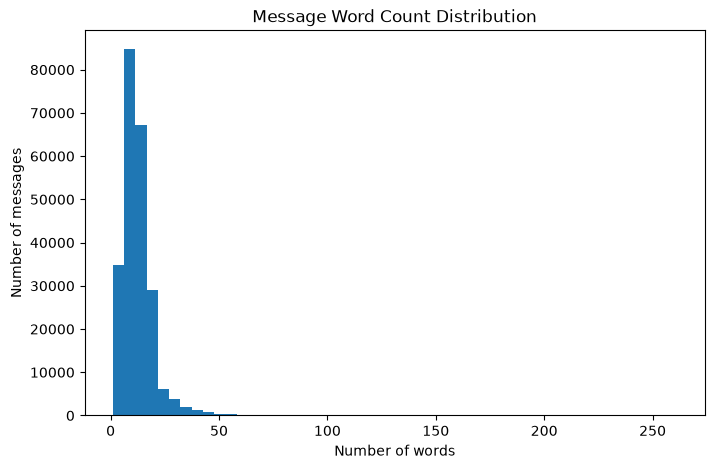

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["word_count"],
    bins=50
)

plt.title("Message Word Count Distribution")
plt.xlabel("Number of words")
plt.ylabel("Number of messages")

plt.show()

In [9]:
df.groupby("dataset")[["character_count", "word_count"]].describe()

character_count                                               \
                      count       mean        std  min   25%   50%   75%   
dataset                                                                    
DailyDialog         99651.0  59.771091  49.224701  1.0  29.0  46.0  75.0   
PersonaChat        131438.0  49.726274  17.843379  1.0  35.0  49.0  64.0   

                    word_count                                              \
                max      count       mean        std  min  25%   50%   75%   
dataset                                                                      
DailyDialog  1158.0    99651.0  13.555067  10.224576  1.0  7.0  11.0  17.0   
PersonaChat   146.0   131438.0  11.674014   4.045545  1.0  8.0  12.0  15.0   

                    
               max  
dataset             
DailyDialog  261.0  
PersonaChat   60.0

Segregation for short and long messages


In [10]:
print("Messages with 1 word or less:")
print((df["word_count"] <= 1).sum())

print("\nMessages with more than 50 words:")
print((df["word_count"] > 50).sum())

print("\nMessages with more than 100 words:")
print((df["word_count"] > 100).sum())

Messages with 1 word or less:
155

Messages with more than 50 words:
1021

Messages with more than 100 words:
46


Emoji 

In [11]:
import re

emoji_pattern = re.compile(
    "["
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "\U00002700-\U000027BF"
    "\U00002600-\U000026FF"
    "]+",
    flags=re.UNICODE
)

def count_emojis(text):
    return len(emoji_pattern.findall(str(text)))

df["emoji_count"] = df["message"].apply(count_emojis)

df["emoji_count"].describe()


emoji_messages = (df["emoji_count"] > 0).sum()

total_messages = len(df)

print("Messages containing emojis:", emoji_messages)
print("Total messages:", total_messages)
print(
    "Percentage:",
    round(emoji_messages / total_messages * 100, 2),
    "%"
)

emoji_by_dataset = (
    df.groupby("dataset")["emoji_count"]
    .agg(
        total_emojis="sum",
        messages_with_emoji=lambda x: (x > 0).sum(),
        average_emojis="mean"
    )
)

emoji_by_dataset

Messages containing emojis: 0
Total messages: 231089
Percentage: 0.0 %


,total_emojis,messages_with_emoji,average_emojis
dataset,,,
DailyDialog,0,0,0.0
PersonaChat,0,0,0.0


Sentences 

In [12]:
sentence_pattern = re.compile(r"[.!?]+")

def count_sentences(text):
    text = str(text).strip()

    if not text:
        return 0

    sentences = sentence_pattern.findall(text)
    return max(len(sentences), 1)

df["sentence_count"] = df["message"].apply(count_sentences)

df["sentence_count"].describe()



df["question_marks"] = df["message"].str.count(r"\?")
df["exclamation_marks"] = df["message"].str.count(r"!")
df["commas"] = df["message"].str.count(",")
df["periods"] = df["message"].str.count(r"\.")

structure_summary = df[
    [
        "sentence_count",
        "question_marks",
        "exclamation_marks",
        "commas",
        "periods"
    ]
].describe()

structure_summary



question_messages = (df["question_marks"] > 0).sum()
exclamation_messages = (df["exclamation_marks"] > 0).sum()

print(
    f"Messages containing a question mark: "
    f"{question_messages} ({question_messages / len(df) * 100:.2f}%)"
)

print(
    f"Messages containing an exclamation mark: "
    f"{exclamation_messages} ({exclamation_messages / len(df) * 100:.2f}%)"
)

Messages containing a question mark: 77677 (33.61%)
Messages containing an exclamation mark: 26101 (11.29%)
